# Supplementary Analysis

## Setup

In [1]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xarray as xr
import pandas as pd


from scipy.signal import sosfiltfilt, butter, sosfilt, welch, savgol_filter
from scipy.stats import entropy, skew, kurtosis, pearsonr, spearmanr, ks_2samp, wasserstein_distance
from scipy.linalg import sqrtm, logm, norm
from scipy.spatial.distance import pdist, cdist
from sklearn.cluster import KMeans

os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.models.WGAN_v0 import WGAN_GP_V0
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)

def generate_data(model, x, sub, pos, n_subjects, latent_dim=128, use_random_sub=False, apply_sub_layer=False, use_global_mean_std=False):
    B, T, C = x.shape
    l = len(x)
    x_gen = torch.zeros((B, T, C))
    bs = x.shape[0]//n_subjects
    random_sub = keras.random.randint(sub.shape, 0, sub.max(), dtype=torch.int64)

    if use_random_sub:
        for i in range(int(l/bs)):
            if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
            else:
                x_mean, x_std = x[i*bs:(i+1)*bs].mean(), x[i*bs:(i+1)*bs].std()
            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    random_sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    else:
        for i in range(int(l/bs)):
            if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
            else:
                x_mean, x_std = x[i*bs:(i+1)*bs].mean(), x[i*bs:(i+1)*bs].std()

            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    # fill in the rest
    tr_sh = (x_gen.shape[0]//bs)*bs
    if tr_sh < B:
        print('creating the residuals')
        res = B - tr_sh
        if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
        else:
            x_mean, x_std = x[-res:].mean(), x[-res:].std()
        x_gen[-res:] = model.generator((keras.random.normal((res, 128), mean=x_mean, stddev=x_std),
                                                sub[-res:].to('mps'),
                                                pos[-res:].to('mps'))).cpu().detach()
    
    # use subject layer in data generation
    if apply_sub_layer:
        print('applying the subject layer...')
        if use_random_sub:
            x_gen = model.generator.layers[0].module(x_gen.to('mps'), random_sub.to('mps')).cpu().detach()
        else:
            x_gen = model.generator.layers[0].module(x_gen.to('mps'), sub.to('mps')).cpu().detach()

    return x_gen

def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    if reverse_first:
        x = reverse_segmentation(x, n_subjects)
    else:
        x = x.permute(0, 2, 1)
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

def plot_time_domain(x, x_gen, time_dim, channels, ax, ch=0):
    x, x_gen = x[:, ch, :time_dim], x_gen[:, ch, :time_dim]
    real_data_avg = x.mean(0)
    fake_data_avg = x_gen.mean(0)
    ax.plot(fake_data_avg, label="Generated", color='orangered')
    ax.plot(real_data_avg, label="Real", color='navy', alpha=0.5)

    ax.fill_between(np.arange(time_dim),
                    real_data_avg - x.std(axis=0),
                    real_data_avg + x.std(axis=0),
                    alpha=0.4, color='navy')
    
    ax.fill_between(np.arange(time_dim),
            fake_data_avg - x_gen.std(axis=0),
            fake_data_avg + x_gen.std(axis=0),
            alpha=0.4, color='orangered')

    ax.set_title(f'Channel {channels[ch]}', fontsize=14, color='blue', loc='left')
    ax.set_xlim([0, time_dim])


def plot_psd_individual_subjects(reversed_x, channels, ax, n_sub_plotted=2, fmin=1, fmax=60, n_fft=512, color='blue'):
    psd, freq = mne.time_frequency.psd_array_welch(reversed_x[:n_sub_plotted], sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    psd = 10*np.log10(psd)
    for n in range(n_sub_plotted):
        for i, c in enumerate(range(len(channels))):
            psd_ = psd[n, c, :]
            ax[i//4, i%4].plot(freq, psd_, label=f'subject {n}', linewidth=2)
            ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
            ax[i//4, i%4].set_xlim([0.7, fmax])

def calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reorder_first'):

    if psd_method == 'reverse_first':
        psd, freq = psd_array_welch(reverse_segmentation(x, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'flat_first':
        psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'reorder_first':
        psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
    
    return psd, psd_gen, freq

def time_domain_features_multi_channel(x, axis=-1):  # x: (n_samples, n_channels, n_timepoints)
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis)
    skewness = skew(x, axis=axis)
    kurtosis_ = kurtosis(x, axis=axis)
    rms = np.sqrt(np.mean(x**2, axis=axis))
    return np.stack([mean, std, skewness, kurtosis_, rms], axis=-1)  # (n_samples, n_channels, n_features)

def hjorth_parameters_multi_channel(signal, axis=-1): 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    mobility = np.sqrt(np.var(first_derivative, axis=axis) / activity)
    second_derivative = np.diff(first_derivative, axis=axis)
    complexity = np.sqrt(np.var(second_derivative, axis=axis) / np.var(first_derivative, axis=axis)) / mobility
    return np.stack([activity, mobility, complexity], axis=-1)

def spectral_features_multi_channel(signal, fs=128, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power
    pxx_entropy = entropy(Pxx, axis=-1)
    return np.stack([delta, theta, alpha, beta, gamma, pxx_entropy], axis=-1)

def aggregate_features(real_signal, gen_signal):
    # Extract features
    real_time_features = time_domain_features_multi_channel(real_signal)
    real_hjorth_features = hjorth_parameters_multi_channel(real_signal)
    real_spectral_features = spectral_features_multi_channel(real_signal)
    
    gen_time_features = time_domain_features_multi_channel(gen_signal)
    gen_hjorth_features = hjorth_parameters_multi_channel(gen_signal)
    gen_spectral_features = spectral_features_multi_channel(gen_signal)
    
    # Concatenate features
    real_features = np.concatenate([real_time_features, real_hjorth_features, real_spectral_features], axis=-1)
    gen_features = np.concatenate([gen_time_features, gen_hjorth_features, gen_spectral_features], axis=-1)
    
    # # Reshape to 2D for FID
    # real_features = real_features.reshape(real_features.shape[0], -1)  # Flatten across channels
    # gen_features = gen_features.reshape(gen_features.shape[0], -1)
    
    return real_features, gen_features

def compute_fid(x_features, y_features):
    # Mean and covariance
    mean1, cov1 = x_features.mean(axis=0), np.cov(x_features, rowvar=False)
    mean2, cov2 = y_features.mean(axis=0), np.cov(y_features, rowvar=False)
    # Mean difference
    mean_diff = np.sum((mean1 - mean2)**2)
    
    # Covariance square root
    covmean = sqrtm(cov1 @ cov2)
    
    # Numerical stability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # FID formula
    fid = mean_diff + np.trace(cov1 + cov2 - 2 * covmean)
    return fid

## DATA

In [3]:
# Data Parameters
FILTERING = True
PREPROCESSING = True
LINE_NOISE_REMOVAL = True
TIME_DIM = 512
N_SUBJECTS = 2
EEG_DATA_PATH = 'data/LEMON_data/EC_ch-8_sf-128.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# Model parameters
LATENT_DIM = 128

# PATHS
STAT_PATH = 'logs/5/20250605_7th.csv'
CHECKPOINTS_PATH = 'logs/5/20250605_7th_epoch_1280.model.keras'

# REAL DATA
xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

sub_id = np.random.randint(0, 202, N_SUBJECTS)
x = xarray.sel(subject=xarray.subject[sub_id], channel=CHANNELS)
x = x.to_numpy()

if PREPROCESSING:
    x = preprocess_data(x, sampling_rate=128)

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

if LINE_NOISE_REMOVAL:
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

x = segment_data(x, TIME_DIM)
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x.shape[0]//N_SUBJECTS)[:, np.newaxis])
pos = torch.tensor(xarray.ch_positions[None].repeat(x.shape[0], 0))
# data = {'x': x, 'sub': sub, 'pos': pos}

>>>>Corrected Mean: 2.9787864134168516e-05, Std: 4.87544603047057e-05, Max: 0.00032455573952522044, Min: -0.0001378491446635783
>>>>Scaled Mean: -0.01356204274766485, Std: 0.7743013990851108, Max: 3.2727762886441885, Min: -3.546112038124475
>>>>Normalized Mean: -9.52941429469926e-17, Std: 0.9999999999999993, Max: 4.126508939411446, Min: -4.563177151979896
>>>>Clamped Mean: -9.52941429469926e-17, Std: 0.9999999999999993, Max: 4.126508939411446, Min: -4.563177151979896
Power of components removed by DSS: 0.02


### Fake Data

In [4]:
# FAKE DATA
model = WGAN_GP_V0(time_dim=512, feature_dim=len(CHANNELS),
                   latent_dim=LATENT_DIM, n_subjects=202,
                   use_sublayer_generator=True,
                   use_sublayer_critic=True,
                   use_channel_merger_g=False,
                   use_channel_merger_c=False,
                   interpolation='bilinear')

# load model and history
model.load_weights(CHECKPOINTS_PATH)

with torch.no_grad():
    x_gen = generate_data(model, x, sub, pos, N_SUBJECTS, latent_dim=LATENT_DIM, apply_sub_layer=False, use_random_sub=False,
                          use_global_mean_std=False)

## Visualizations

In [ ]:
_, ax = plt.subplots(2, 4, figsize=(20, 8))
plot_psd_multi_channel(x, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True)
plot_psd_multi_channel(x_gen, CHANNELS, ax, n_subjects=N_SUBJECTS, color='red', reverse_first=True)

In [ ]:
# fig, ax = plt.subplots(2, 4, figsize=(20, 8))
# plot_psd_individual_subjects(reverse_segmentation(x_gen, N_SUBJECTS).numpy(), CHANNELS, ax, n_sub_plotted=5)
# plot_psd_individual_subjects(reverse_segmentation(x, N_SUBJECTS).numpy(), CHANNELS, ax, n_sub_plotted=5)

fig, ax = plt.subplots(8, 1, figsize=(20, 16))
for i, ch in enumerate(range(len(CHANNELS))):
        plot_time_domain(reverse_segmentation(x, N_SUBJECTS), reverse_segmentation(x_gen, N_SUBJECTS), 4096, CHANNELS, ax[i], ch)

plt.legend()
plt.show()

## Metrics for features similarity
### frequency domain

In [ ]:
real_psd, fake_psd, freqs = calculate_psd_different_methods(x, x_gen, 202, method='reorder_first')

# correlation between real and fake psd
corr, _ = pearsonr(real_psd.mean(0), fake_psd.mean(0), axis=1)
r_s, _ = spearmanr(real_psd.mean(0), fake_psd.mean(0), axis=1)
print(r_s.mean(), corr.mean())

0.9920835373835738 0.9650752518031476


### Statistical features of the timeseries

In [ ]:
fids = {}
for j, func in enumerate([hjorth_parameters_multi_channel,
                          spectral_features_multi_channel,
                          time_domain_features_multi_channel]):

    real_f = func(x.permute(0, 2, 1).cpu().detach().numpy())
    gen_f = func(x_gen.permute(0, 2, 1).cpu().detach().numpy())
    from scipy.stats import zscore

    real_f = zscore(real_f, axis=0)
    gen_f = zscore(gen_f, axis=0)
    print(f'Correlation on {func.__name__[:-14]}: {pearsonr(real_f, gen_f, axis=-1)[0].mean()}')  # TODO: consider standardizing the features before computing FID

corr_ts, _ = pearsonr(x_gen.mean(0), x.mean(0), axis=0)
print(f'correlation of averaged segments: {corr_ts.mean()}')

## Fréchet Distance between features

In [ ]:
def creat_df4FD(all_wd):
    all_wd_df = pd.DataFrame(all_wd, index=[0])
    all_wd_df = all_wd_df.melt(var_name='name', value_name='WD')
    all_wd_df[['channel', 'feature']] = all_wd_df['name'].apply(lambda x: x.split('_')).apply(pd.Series)
    all_wd_df.drop('name', axis=1, inplace=True)
    all_wd_df = all_wd_df.pivot(columns='feature', values='WD', index=['channel'])
    
    all_wd_df.reset_index(inplace=True)
    all_wd_df.set_index(['channel'], inplace=True)
    return all_wd_df

In [19]:
f_names = ['mean', 'std', 'skewness', 'kurtosis', 'rms', 'activity', 'mobility', 'complexity',
           'delta', 'theta', 'alpha', 'beta', 'gamma', 'entropy']

all_wd = {}
bs = 128
reverse = False

if reverse:
    real_f, fake_f = aggregate_features(reverse_segmentation(x, N_SUBJECTS).cpu().detach().numpy(),
                                        reverse_segmentation(x_gen, N_SUBJECTS).cpu().detach().numpy()) 

else:
    real_f, fake_f = aggregate_features(x.permute(0, 2, 1).cpu().detach().numpy(),
                                        x_gen.permute(0, 2, 1).cpu().detach().numpy())

for ch in range(0, len(CHANNELS), 2):
    for fn in range(len(f_names)):
        all_wd[f'{CHANNELS[ch]}_{f_names[fn]}'] = compute_fid(real_f[:, [ch, ch+1], fn],
                                                              fake_f[:, [ch, ch+1], fn])

if reverse:
    all_wd_df_r = creat_df4FD(all_wd)
else:
    all_wd_df = creat_df4FD(all_wd)

In [ ]:
fig, axes = plt.subplots(8, 14, figsize=(40, 20))
brain_areas = ['occipital', 'parietal', 'central', 'frontal']
for ch_idx in range(len(CHANNELS)):
    for fn in range(len(f_names)):
        sns.histplot(real_f[:, ch_idx, fn], color='blue', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='real', stat='density')
        sns.histplot(fake_f[:, ch_idx, fn], color='red', kde=False, element='poly', fill=False, ax=axes[ch_idx, fn], label='fake', stat='density')
        axes[ch_idx, fn].legend()
        if ch_idx == 0:
            axes[ch_idx, fn].set_title(f_names[fn], fontsize=18, color='blue')
        if fn == 0:
            axes[ch_idx, fn].set_ylabel(CHANNELS[ch_idx], fontsize=18, color='blue')
        else:
            axes[ch_idx, fn].set_ylabel('')
fig.suptitle('Feature Distribution Comparison: Real vs. Fake (Final Epoch)', color='blue', fontsize=20)
plt.show()

## Functional Connectivity
### Coherence

In [2]:
from mne_connectivity import spectral_connectivity_time, envelope_correlation

SUBJECT_WISE = True

def plot_connectivity(conn_real, conn_fake, vmin=0, vmax=1.4):
    _, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(conn_real, vmin=vmin, vmax=vmax, ax=ax[0], annot=True)
    ax[0].set_title('Real data')
    sns.heatmap(conn_fake, vmin=vmin, vmax=vmax, ax=ax[1], annot=True)
    ax[1].set_title('Generated data')

    plt.tight_layout()

def spectral_coonnectivity_subject_wise(x, N_SUBJECTS, fmin, fmax):
    all_conns = np.zeros([N_SUBJECTS, 8, 8, 5])
    x_rev = reverse_segmentation(x, N_SUBJECTS).numpy()
    for i in range(N_SUBJECTS):
        x_ind = np.array(np.array_split(x_rev[i], 16, axis=1))  # 30 seconds segments
        print(f'>>>>> subject {i+1}')
        cons_ind = spectral_connectivity_time(x_ind, freqs=np.arange(1, 45, 1), method='coh', sfreq=128, n_jobs=1, fmin=fmin, fmax=fmax, verbose=0, average=True, faverage=True)
        all_conns[i, ...] = cons_ind.get_data(output='dense')
    return all_conns

fs = 128
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45),
}
band_names = list(bands.keys())
fmin = np.array([lo for (lo, hi) in bands.values()], dtype=float)
fmax = np.array([hi for (lo, hi) in bands.values()], dtype=float)

In [3]:
if os.path.exists('logs/static_f/conn_real.npy'):
    conn_real = np.load('logs/static_f/conn_real.npy')
    conn_fake = np.load('logs/static_f/conn_fake.npy')

else:
    if SUBJECT_WISE:
        conn_real = spectral_coonnectivity_subject_wise(x, N_SUBJECTS, fmin, fmax)
        conn_fake = spectral_coonnectivity_subject_wise(x_gen, N_SUBJECTS, fmin, fmax)
        # # # save conns
        # np.save('logs/connectivities/conn_real.npy', conn_real)
        # np.save('logs/connectivities/conn_fake.npy', conn_fake)
    else:
        x_real_conn = x.flatten(0, 1).reshape(-1, 7680, 8).permute(0, 2, 1).numpy()
        x_fake_conn = x_gen.flatten(0, 1).reshape(-1, 7680, 8).permute(0, 2, 1).numpy()

        cons_real = spectral_connectivity_time(x_real_conn, freqs=np.arange(1, 45, 1), method='coh', sfreq=128, n_jobs=1, fmin=fmin, fmax=fmax, verbose=0, average=True, faverage=True)
        cons_fake = spectral_connectivity_time(x_fake_conn, freqs=np.arange(1, 45, 1), method='coh', sfreq=128, n_jobs=1, fmin=fmin, fmax=fmax, verbose=0, average=True, faverage=True)

        fb = 4
        coh_real = cons_real.get_data(output='dense')[..., fb]
        coh_fake = cons_fake.get_data(output='dense')[..., fb]

#### Visualisation

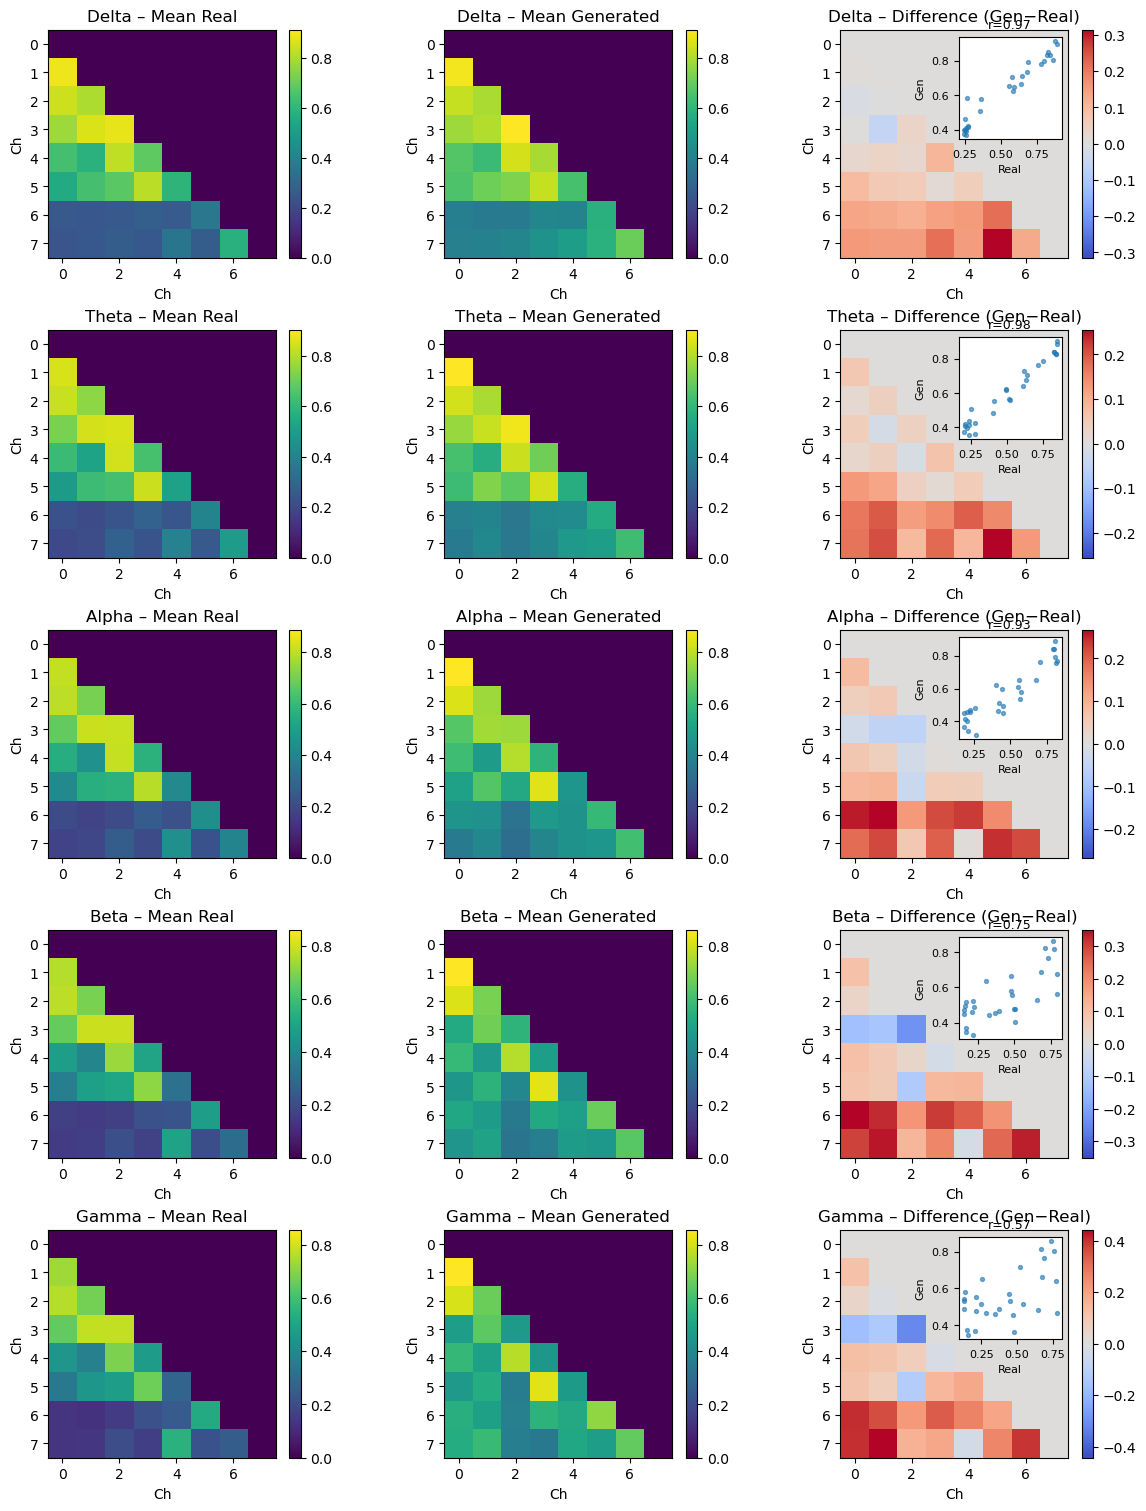

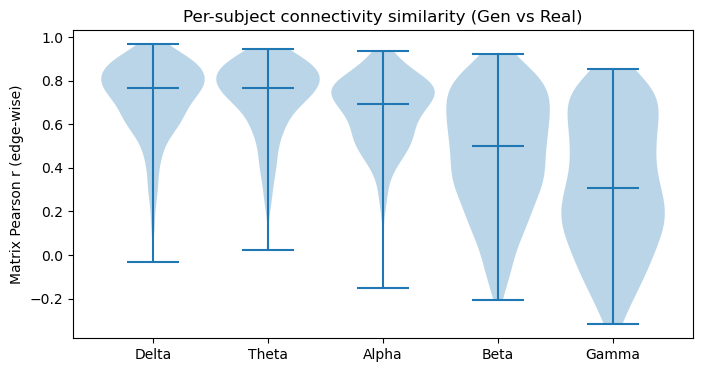

Delta : r_med=0.77 [IQR 0.22]  EMD=0.091 [IQR 0.087]
Theta : r_med=0.77 [IQR 0.19]  EMD=0.100 [IQR 0.091]
Alpha : r_med=0.69 [IQR 0.24]  EMD=0.100 [IQR 0.065]
Beta  : r_med=0.50 [IQR 0.40]  EMD=0.117 [IQR 0.072]
Gamma : r_med=0.31 [IQR 0.50]  EMD=0.137 [IQR 0.084]


In [4]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# helper functions
def tri_lower(vec_mat):
    iu = np.tril_indices_from(vec_mat, k=-1)
    return vec_mat[iu]

def safe_pearson(a, b):
    # returns nan if either vector is constant
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return pearsonr(a, b).correlation

def band_summaries(r_matrix, wd_matrix):
    # r_matrix, wd_matrix: (n_subj, n_bands)
    med_r   = np.nanmedian(r_matrix, axis=0)
    iqr_r   = np.nanpercentile(r_matrix, 75, axis=0) - np.nanpercentile(r_matrix, 25, axis=0)
    med_wd  = np.nanmedian(wd_matrix, axis=0)
    iqr_wd  = np.nanpercentile(wd_matrix, 75, axis=0) - np.nanpercentile(wd_matrix, 25, axis=0)
    return med_r, iqr_r, med_wd, iqr_wd


# Move bands to axis=1 -> (n_subj, n_bands, n_ch, n_ch) for convenience
real = np.transpose(conn_real, (0, 3, 1, 2)).astype(float)
fake = np.transpose(conn_fake, (0, 3, 1, 2)).astype(float)

n_subj, n_bands, n_ch, _ = real.shape
band_names = ['Delta','Theta','Alpha','Beta','Gamma'][:n_bands]

# Per-subject metrics
r_per_subj  = np.zeros((n_subj, n_bands)) * np.nan
wd_per_subj = np.zeros((n_subj, n_bands)) * np.nan

for s in range(n_subj):
    for b in range(n_bands):
        vr = tri_lower(real[s, b])
        vg = tri_lower(fake[s, b])
        r_per_subj[s, b]  = safe_pearson(vr, vg)
        wd_per_subj[s, b] = wasserstein_distance(vr, vg)

# Summaries
med_r, iqr_r, med_wd, iqr_wd = band_summaries(r_per_subj, wd_per_subj)

# Mean matrices & differences (for the composite figure)
mean_real = np.nanmean(real, axis=0)   # (n_bands, n_ch, n_ch)
mean_fake = np.nanmean(fake, axis=0)
diff_mat  = mean_fake - mean_real

# ---------- composite figure: mean real / mean fake / difference with inset scatter
fig, axes = plt.subplots(n_bands, 3, figsize=(12, 3*n_bands), constrained_layout=True)
if n_bands == 1:
    axes = axes[np.newaxis, :]  # keep 2D for consistent indexing

for b in range(n_bands):
    # consistent color scaling per band
    vmin = 0.0
    vmax = max(np.nanmax(mean_real[b]), np.nanmax(mean_fake[b]))
    im0 = axes[b,0].imshow(mean_real[b], vmin=vmin, vmax=vmax)
    axes[b,0].set_title(f"{band_names[b]} – Mean Real")
    axes[b,0].set_xlabel("Ch"); axes[b,0].set_ylabel("Ch")
    fig.colorbar(im0, ax=axes[b,0], fraction=0.046, pad=0.04)

    im1 = axes[b,1].imshow(mean_fake[b], vmin=vmin, vmax=vmax)
    axes[b,1].set_title(f"{band_names[b]} – Mean Generated")
    axes[b,1].set_xlabel("Ch"); axes[b,1].set_ylabel("Ch")
    fig.colorbar(im1, ax=axes[b,1], fraction=0.046, pad=0.04)

    # difference panel
    dmax = np.nanmax(np.abs(diff_mat[b]))
    im2 = axes[b,2].imshow(diff_mat[b], vmin=-dmax, vmax=dmax, cmap='coolwarm')
    axes[b,2].set_title(f"{band_names[b]} – Difference (Gen−Real)")
    axes[b,2].set_xlabel("Ch"); axes[b,2].set_ylabel("Ch")
    fig.colorbar(im2, ax=axes[b,2], fraction=0.046, pad=0.04)

    # inset: edge scatter with Spearman r
    ax_in = inset_axes(axes[b,2], width="45%", height="45%", loc='upper right')
    vr = tri_lower(mean_real[b]); vg = tri_lower(mean_fake[b])
    ax_in.scatter(vr, vg, s=8, alpha=0.6)
    r_ins = safe_pearson(vr, vg)
    ax_in.set_title(f"r={np.nan_to_num(r_ins):.2f}", fontsize=9)
    ax_in.set_xlabel("Real", fontsize=8); ax_in.set_ylabel("Gen", fontsize=8)
    ax_in.tick_params(labelsize=8)

plt.show()

# ---------- violins: per-subject matrix correlation (individual differences) ----------
fig2, ax2 = plt.subplots(figsize=(8, 4))
# build list of arrays per band (drop nans)
data_r = [r_per_subj[:, b][~np.isnan(r_per_subj[:, b])] for b in range(n_bands)]
vp = ax2.violinplot(data_r, showmedians=True, widths=0.9)
ax2.set_xticks(np.arange(1, n_bands+1)); ax2.set_xticklabels(band_names)
ax2.set_ylabel("Matrix Pearson r (edge-wise)")
ax2.set_title("Per-subject connectivity similarity (Gen vs Real)")
plt.show()

# ---------- print concise summaries for the paper ----------
for b, name in enumerate(band_names):
    print(f"{name:6s}: r_med={med_r[b]:.2f} [IQR {iqr_r[b]:.2f}]  "
          f"EMD={med_wd[b]:.3f} [IQR {iqr_wd[b]:.3f}]")

### Topology of Real and Generated Connectivity Clouds

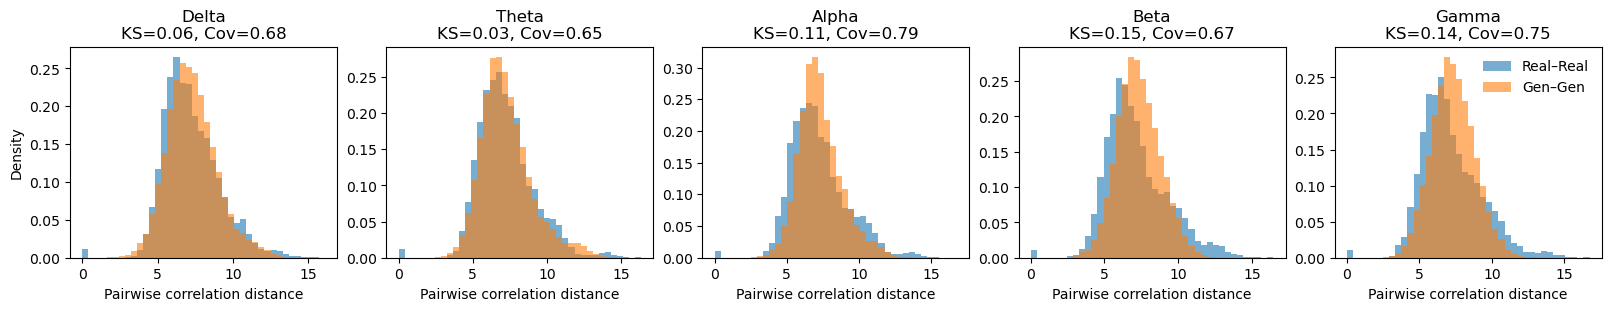

Delta  | KS=0.062  Coverage=0.68
Theta  | KS=0.034  Coverage=0.65
Alpha  | KS=0.114  Coverage=0.79
Beta   | KS=0.152  Coverage=0.67
Gamma  | KS=0.136  Coverage=0.75


In [4]:
dmeasure = 'mahalanobis'
# dmeasure = 'correlation'

def edge_vectors(conn):
    n_subj, n_ch, _, n_bands = conn.shape
    iu = np.tril_indices(n_ch, k=-1)
    V = conn[:, iu[0], iu[1], :].reshape(n_subj, iu[0].shape[0], n_bands)
    return V

def preprocess(V):
    mu = V.mean(axis=0, keepdims=True)
    sd = V.std(axis=0, keepdims=True)
    keep = (sd > 0)
    Vz = (V[:, keep[0, :]] - mu[:, keep[0, :]]) / (sd[:, keep[0, :]])
    return Vz

def nn_stats_corr(X_real, X_gen, ref_percentile=95, eps=1e-8):
    Drg = cdist(X_gen, X_real, metric=dmeasure)  # gen->real
    nn_gr = Drg.min(axis=1)

    Drr = cdist(X_real, X_real, metric=dmeasure)
    np.fill_diagonal(Drr, np.inf)
    nn_rr = Drr.min(axis=1)

    thresh = np.percentile(nn_rr, ref_percentile)
    coverage = float(np.mean(nn_gr <= thresh))
    ratio = float(np.median(nn_gr) / (np.median(nn_rr) + eps))
    return nn_gr, nn_rr, coverage, ratio

def geometry_analysis_corr(conn_real, conn_fake, band_names=None, bins=40):
    V_real = edge_vectors(conn_real)  # (n_subj, n_edges, n_bands)
    V_gen  = edge_vectors(conn_fake)
    n_subj, n_edges, n_bands = V_real.shape
    if band_names is None:
        band_names = ['Delta','Theta','Alpha','Beta','Gamma'][:n_bands]

    KS, COV, RATIO, PVALUES = np.zeros(n_bands), np.zeros(n_bands), np.zeros(n_bands), np.zeros(n_bands)

    fig, axes = plt.subplots(1, n_bands, figsize=(3.2*n_bands, 3.0), constrained_layout=True)

    for b in range(n_bands):
        if dmeasure == 'correlation':  # normalize if using correlation distance
            Xr = preprocess(V_real[..., b])
            Xg = preprocess(V_gen[..., b])
        else:
            Xr, Xg = V_real[..., b], V_gen[..., b]

        # within-set condensed distances (correlation distance)
        Dr = pdist(Xr, metric=dmeasure)
        Dg = pdist(Xg, metric=dmeasure)

        KS[b], _ = ks_2samp(Dr, Dg)
        nn_gr, nn_rr, cov, rat = nn_stats_corr(Xr, Xg)
        COV[b], RATIO[b] = cov, rat

        ax = axes[b] if n_bands > 1 else axes
        lo, hi = min(Dr.min(), Dg.min()), max(Dr.max(), Dg.max())
        ax.hist(Dr, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Real–Real')
        ax.hist(Dg, bins=bins, range=(lo, hi), alpha=0.6, density=True, label='Gen–Gen')
        # sns.ecdfplot(Dr, ax=ax)
        # sns.ecdfplot(Dg, ax=ax)
        ax.set_title(f'{band_names[b]}\nKS={KS[b]:.02f}, Cov={cov:.02f}')
        ax.set_xlabel('Pairwise correlation distance')
        if b == 0: ax.set_ylabel('Density')
        if b == n_bands-1: ax.legend(frameon=False)

    plt.show()

    for b, name in enumerate(band_names):
        print(f"{name:6s} | KS={KS[b]:.03f}  Coverage={COV[b]:.02f}")

    # return {'KS': KS, 'coverage': COV, 'ratio': RATIO}
    return Dr, Dg

# results = geometry_analysis_corr(conn_real, conn_fake, band_names=['Delta','Theta','Alpha','Beta','Gamma'])
Dr, Dg = geometry_analysis_corr(conn_real, conn_fake, band_names=['Delta','Theta','Alpha','Beta','Gamma'])

In [ ]:
from scipy.spatial.distance import squareform

metric ='mahalanobis'

def _knn_radii(X, k=5, metric=metric):
    """
    k-NN radius per point inside X.
    X: (N, D)
    returns: radii (N,)
    """
    D = squareform(pdist(X, metric=metric))  # (N, N)
    np.fill_diagonal(D, np.inf)             # ignore self-distance
    # distance to k-th nearest neighbor (k starting at 1)
    radii = np.partition(D, k-1, axis=1)[:, k-1]
    return radii

def precision_recall_kynkaanyemi(X_real, X_gen, k=5, metric=metric):
    Xr = np.asarray(X_real, float)
    Xg = np.asarray(X_gen,  float)
    Nr, Ng = Xr.shape[0], Xg.shape[0]

    # 1) Local radii in each set
    r_r = _knn_radii(Xr, k=k, metric=metric)  # (N_r,)
    r_g = _knn_radii(Xg, k=k, metric=metric)  # (N_g,)

    # 2) Cross distances between real and gen
    D_rg = cdist(Xr, Xg, metric=metric)       # (N_r, N_g)

    # ----- Precision: fraction of gen points inside real manifold -----
    # For each gen j, check if there exists real i with d_ij <= r_r[i]
    inside_real = (D_rg <= r_r[:, None])      # (N_r, N_g) boolean
    precision = inside_real.any(axis=0).mean()

    # ----- Recall: fraction of real points inside gen manifold -----
    # For each real i, check if there exists gen j with d_ij <= r_g[j]
    inside_gen = (D_rg <= r_g[None, :])       # (N_r, N_g) boolean
    recall = inside_gen.any(axis=1).mean()

    return float(precision), float(recall)

V_real = edge_vectors(conn_real)
V_fake = edge_vectors(conn_fake)

for b in range(5):
    Xr, Xg = V_real[..., b], V_fake[..., b]
    p, r = precision_recall_kynkaanyemi(Xr, Xg)
    print(p, r)

0.9257425742574258 0.6336633663366337
0.9108910891089109 0.6534653465346535
0.9405940594059405 0.504950495049505
0.9900990099009901 0.44554455445544555
0.9851485148514851 0.5742574257425742


### LDA and PCA projection of connectivity distributions per band

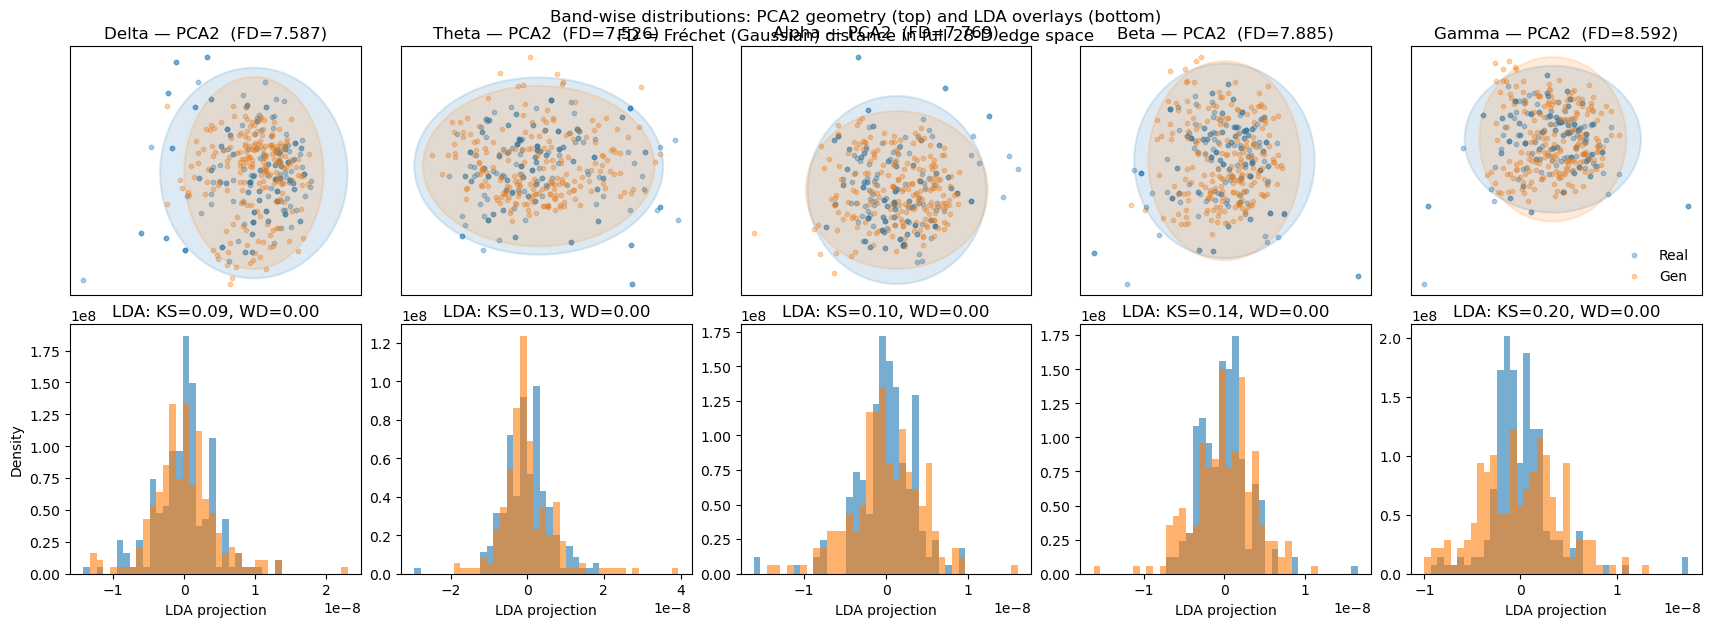

In [ ]:
from numpy.linalg import eigh, inv

def edge_vectors(conn):
    n_subj, n_ch, _, n_bands = conn.shape
    iu = np.tril_indices(n_ch, k=-1)
    V = conn[:, iu[0], iu[1], :].reshape(n_subj, iu[0].shape[0], n_bands)
    return V
Vr = edge_vectors(conn_real)
Vg = edge_vectors(conn_fake)

def fd_gaussian(X, Y):
    mu1, mu2 = X.mean(0), Y.mean(0)
    S1 = np.cov(X, rowvar=False)
    S2 = np.cov(Y, rowvar=False)
    C = sqrtm(S1 @ S2)
    if np.iscomplexobj(C): C = C.real
    diff = mu1 - mu2
    return float(diff @ diff + np.trace(S1 + S2 - 2*C))

def fisher_lda_direction(Xr, Xg, eps=1e-6):
    mu_r, mu_g = Xr.mean(0), Xg.mean(0)
    Sr = np.cov(Xr, rowvar=False); Sg = np.cov(Xg, rowvar=False)
    Sw = Sr + Sg + eps*np.eye(Sr.shape[0])
    w = inv(Sw) @ (mu_r - mu_g)
    return w / (np.linalg.norm(w) + eps)

def zscore_cols(A):
    m = A.mean(0, keepdims=True); s = A.std(0, keepdims=True)
    s[s==0] = 1.0
    return (A - m) / s

# ---- plotting helpers ----
def pca_2d(X):
    # centered PCA -> 2D
    Xm = X - X.mean(0, keepdims=True)
    C = np.cov(Xm, rowvar=False)
    vals, vecs = eigh(C)
    U = vecs[:, -2:]          # top-2
    Z = Xm @ U                # (n,2)
    return Z, U, vals[-2:]

def plot_cov_ellipse(ax, X, color, alpha=0.12, level=5.991):  # 95% for chi2_2 ~ 5.991
    mu = X.mean(0)
    C = np.cov(X - mu, rowvar=False)
    vals, vecs = eigh(C)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2*np.sqrt(level*vals)
    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    from matplotlib.patches import Ellipse
    e = Ellipse(xy=mu, width=width, height=height, angle=angle,
                facecolor=color, edgecolor=color, alpha=alpha, lw=1.5)
    ax.add_patch(e)

def plot_band_distributions(Vr, Vg, band_names=None, bins=40):
    n_subj, n_feat, n_bands = Vr.shape
    if band_names is None:
        band_names = [f'Band {i+1}']*n_bands

    fig, axes = plt.subplots(2, n_bands, figsize=(3.4*n_bands, 6.0), constrained_layout=True)

    for b in range(n_bands):
        Xr = zscore_cols(Vr[:, :, b])
        Xg = zscore_cols(Vg[:, :, b])

        # --- FD(b)
        FD = fd_gaussian(Xr, Xg)

        # --- Top: 2D PCA scatter + 95% ellipses (per band)
        Zr, _, _ = pca_2d(Xr)
        Zg, _, _ = pca_2d(Xg)

        ax = axes[0, b] if n_bands > 1 else axes[0]
        ax.scatter(Zr[:,0], Zr[:,1], s=10, alpha=0.35, label='Real', color='#1f77b4')
        ax.scatter(Zg[:,0], Zg[:,1], s=10, alpha=0.35, label='Gen',  color='#ff7f0e')
        plot_cov_ellipse(ax, Zr, color='#1f77b4', alpha=0.15)
        plot_cov_ellipse(ax, Zg, color='#ff7f0e', alpha=0.15)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{band_names[b]} — PCA2  (FD={FD:.3f})')
        if b == n_bands-1: ax.legend(frameon=False, loc='best')

        # --- Bottom: LDA 1-D overlayed hist (per band)
        w = fisher_lda_direction(Xr, Xg)
        pr = Xr @ w; pg = Xg @ w
        ks = ks_2samp(pr, pg).statistic
        wd = wasserstein_distance(pr, pg)

        ax2 = axes[1, b] if n_bands > 1 else axes[1]
        lo, hi = min(pr.min(), pg.min()), max(pr.max(), pg.max())
        ax2.hist(pr, bins=bins, range=(lo, hi), density=True, alpha=0.6, label='Real')
        ax2.hist(pg, bins=bins, range=(lo, hi), density=True, alpha=0.6, label='Gen')
        ax2.set_xlabel('LDA projection'); 
        if b == 0: ax2.set_ylabel('Density')
        ax2.set_title(f'LDA: KS={ks:.02f}, WD={wd:.02f}')

    fig.suptitle('Band-wise distributions: PCA2 geometry (top) and LDA overlays (bottom)\nFD = Fréchet (Gaussian) distance in full 28-D edge space', y=1.02)
    plt.show()

plot_band_distributions(Vr, Vg, band_names=['Delta','Theta','Alpha','Beta','Gamma'])

### Correlation

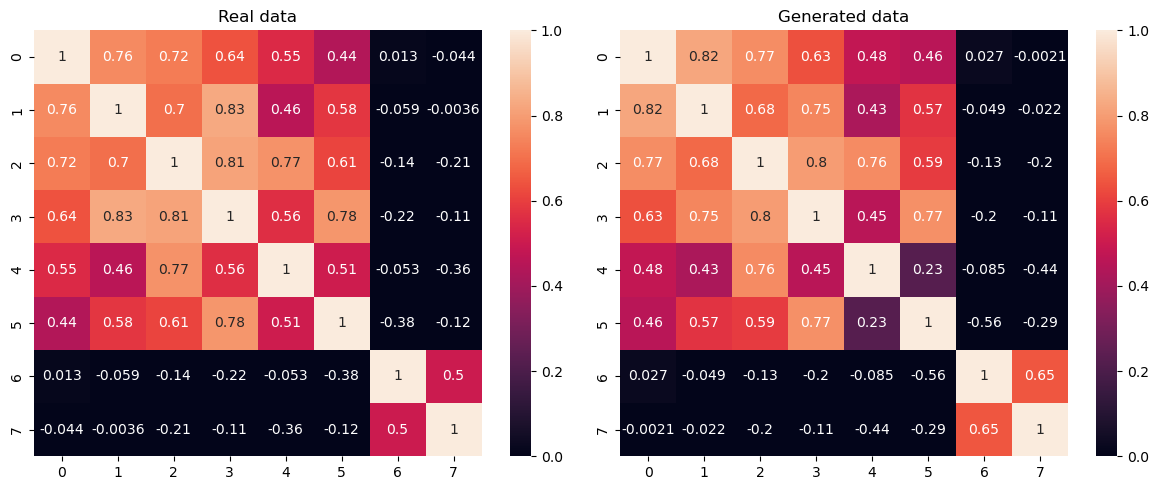

In [ ]:
# data: (n_channels, n_times)
BAND_SPECIFIC = True

if BAND_SPECIFIC:
    x_real_conn = x.flatten(0, 1).T.numpy()
    x_fake_conn = x_gen.flatten(0, 1).T.to(torch.float64).numpy()

    # fileter for alpha band
    sos = butter(4, [8, 13], btype='bandpass', fs=128, output='sos')
    x_real_alpha = sosfiltfilt(sos, x_real_conn, axis=-1)
    x_fake_alpha = sosfiltfilt(sos, x_fake_conn, axis=-1)


    corr_real = np.corrcoef(x_real_alpha) 
    corr_fake = np.corrcoef(x_fake_alpha) 

    plot_connectivity(corr_real, corr_fake)

else:
    corr_real = np.corrcoef(x.flatten(0, 1).T.numpy()) 
    corr_fake = np.corrcoef(x_gen.flatten(0, 1).T.numpy()) 

    plot_connectivity(corr_real, corr_fake)

### Envelope Correlation

In [ ]:
# Envelope Correlation
def get_connectivity(epochs,
                     frequencies: dict,
                     sfreq: float = 128,
):
    def bp_gen(epochs, fmin, fmax, sfreq):
        for ts in epochs:
            yield mne.filter.filter_data(ts, sfreq=sfreq, l_freq=fmin, h_freq=fmax)
    
    conns = {} 
    for bp in frequencies.keys():
        conn_obj = envelope_correlation(bp_gen(epochs, frequencies[bp][0], frequencies[bp][1], sfreq), orthogonalize=False)
        conn = conn_obj.combine()
        conn = conn.get_data(output='dense')[..., 0]
        conns[bp] = conn_obj
        
    return conns

x_real_conn = x.flatten(0, 1).reshape(-1, 61440, 8).permute(0, 2, 1).numpy()
x_fake_conn = x_gen.flatten(0, 1).reshape(-1, 61440, 8).permute(0, 2, 1).to(torch.float64).numpy()

conn_real = get_connectivity(x_real_conn, bands)
conn_fake = get_connectivity(x_fake_conn, bands)

band = list(bands.keys())[0]
plot_connectivity(conn_real[band], conn_fake[band])

### Gaussian-copula MI  

In [ ]:
from scipy.stats import rankdata, norm  

def gcmi(x, y):
    # x, y: 1D arrays (e.g., band envelopes), same length
    ux = rankdata(x) / (len(x) + 1.0)
    uy = rankdata(y) / (len(y) + 1.0)
    gx, gy = norm.ppf(ux), norm.ppf(uy)
    r = np.corrcoef(gx, gy)[0, 1]
    r = np.clip(r, -0.999999, 0.999999)
    return -0.5 * np.log(1.0 - r*r)

# Pairwise GCMI across channels (n_ch x n_ch)
def band_gcmi_matrix(env):  # env: (n_channels, n_time)
    n = env.shape[0]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            M[i, j] = M[j, i] = gcmi(env[i], env[j])
    return M

gcmi_real = band_gcmi_matrix(x.flatten(0, 1).T.numpy())
gcmi_fake = band_gcmi_matrix(x_gen.flatten(0, 1).T.numpy())
plot_connectivity(gcmi_real, gcmi_fake, 0, 1.2)

## Topology of real and fake spectral features 

In [16]:
# quantify PSD
if os.path.exists('logs/static_f/psd_real.npy'):
    psd_real, psd_fake = np.load('logs/static_f/psd_real.npy'), np.load('logs/static_f/psd_fake.npy')
    freqs = np.arange(1, 60.25, 0.25)
else:
    psd_real, psd_fake, freqs = calculate_psd_different_methods(x, x_gen, N_SUBJECTS, psd_method='reverse_first')

{'KS': 0.4186000689621201, 'coverage': 0.8811881188118812, 'knn_ratio': 1.164039067055178}


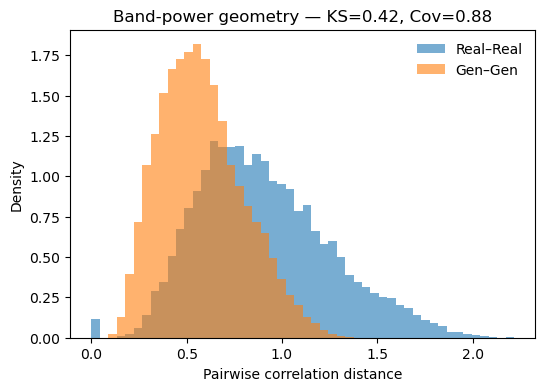

{'KS': 0.19506428254765773, 'coverage': 0.8415841584158416, 'knn_ratio': 1.1039936320926302}


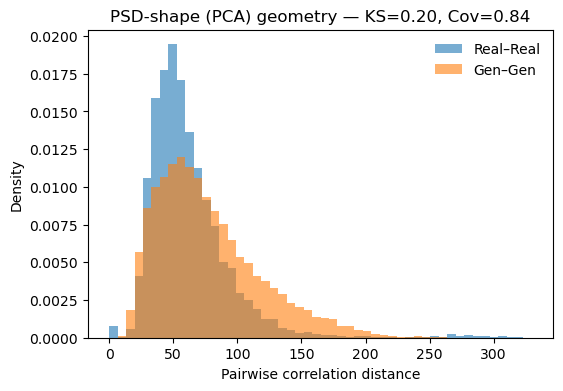

In [9]:
# ---------- utilities  ----------
def zscore_cols(A):
    mu = A.mean(0, keepdims=True); sd = A.std(0, keepdims=True)
    keep = (sd > 0)
    return (A[:, keep[0]] - mu[:, keep[0]]) / sd[:, keep[0]]

def condensed_corr_dists(X):
    return pdist(X, metric='euclidean')

def knn_radius(X, Y, k=5):
    D = cdist(X, Y, metric='euclidean')
    return np.partition(D, k-1, axis=1)[:, k-1]

# ---------- spectral feature builders ----------
bands = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}

def bandpower_topo(psd, freqs):
    # psd: (n_subj, 8, n_freq)  -> (n_subj, 40)
    total = psd.sum(axis=-1, keepdims=True) + 1e-12
    feats = []
    for (f1, f2) in bands.values():
        m = (freqs >= f1) & (freqs < f2)
        feats.append(psd[..., m].sum(axis=-1) / total.squeeze(-1))
    return np.concatenate(feats, axis=-1)

def pca_channel_concat(psd, k=5):
    # per-channel PCA on log-PSD, keep k scores/channel  -> (n_subj, 8*k)
    n_subj, n_ch, _ = psd.shape
    out = []
    for ch in range(n_ch):
        X = np.log(psd[:, ch, :] + 1e-12)
        U, S, _ = np.linalg.svd(X - X.mean(0, keepdims=True), full_matrices=False)
        out.append(U[:, :k] * S[:k])
    return np.concatenate(out, axis=1)

# ---------- plotting helper ----------
def plot_distance_distributions(X_real, X_fake, title='', bins=50):
    Xr, Xg = zscore_cols(X_real), zscore_cols(X_fake)
    Dr, Dg = condensed_corr_dists(X_real), condensed_corr_dists(X_fake)

    # Coverage: fraction of gen→real kNN radii within P95 of real→real kNN radii
    r_gr = knn_radius(Xg, Xr, k=5)
    r_rr = knn_radius(Xr, Xr, k=5)
    cov = float(np.mean(r_gr <= np.percentile(r_rr, 95)))
    ks  = float(ks_2samp(Dr, Dg).statistic)
    ratio = float(np.median(r_gr) / (np.percentile(r_rr, 75) + 1e-6))

    lo, hi = min(Dr.min(), Dg.min()), max(Dr.max(), Dg.max())
    plt.hist(Dr, bins=bins, range=(lo, hi), density=True, alpha=0.60, label='Real–Real')
    plt.hist(Dg, bins=bins, range=(lo, hi), density=True, alpha=0.60, label='Gen–Gen')
    plt.xlabel('Pairwise correlation distance'); plt.ylabel('Density')
    ttl = title + ('' if not title else ' — ') + f'KS={ks:.02f}, Cov={cov:.02f}'
    plt.title(ttl); plt.legend(frameon=False)
    
    print({'KS': ks, 'coverage': cov, 'knn_ratio': ratio})


# band-power topography (40-D)
XA_real = bandpower_topo(psd_real, freqs) # psd_real, psd_fake: (n_subj, 8, 237)
XA_fake = bandpower_topo(psd_fake, freqs)

plt.figure(figsize=(6,4))
plot_distance_distributions(XA_real, XA_fake, title='Band-power geometry')
plt.show()

# PSD shape via PCA per channel (8×k, here k=5 → 40-D)
XB_real = pca_channel_concat(psd_real, k=5)
XB_fake = pca_channel_concat(psd_fake, k=5)

plt.figure(figsize=(6,4))
plot_distance_distributions(XB_real, XB_fake, title='PSD-shape (PCA) geometry')
plt.show()

### IAF

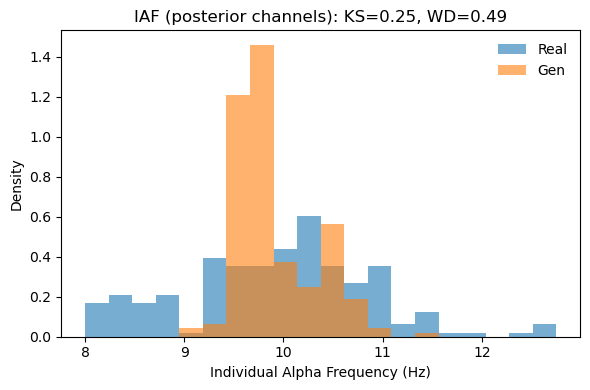

Real IAF: median=10.00 Hz, IQR=(9.25, 10.50)
Gen  IAF: median=9.75 Hz, IQR=(9.50, 10.19)
KS=0.252, WD=0.494


In [9]:
from scipy.signal import savgol_filter

def compute_iaf(psd, freqs, posterior_ch_idx=(0, 1, 2, 3), fmin=8.0, fmax=13.0):
    """Return IAF (Hz) per subject using posterior-average log-PSD peak."""
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    f_band = freqs[band_mask]
    n_subj = psd.shape[0]
    iaf = np.full(n_subj, np.nan)

    # Savitzky–Golay smoothing window (odd, ~1/10 of band points, >=5)
    w = max(5, (len(f_band) // 10) | 1)  # make odd
    for s in range(n_subj):
        p = psd[s, posterior_ch_idx].mean(axis=0)           # average posterior
        lp = np.log(np.clip(p, 1e-12, None))                # log-PSD
        lp_band = lp[band_mask]
        lp_smooth = savgol_filter(lp_band, window_length=w, polyorder=3, mode='interp')
        peak_idx = np.argmax(lp_smooth)
        iaf[s] = f_band[peak_idx]
    return iaf

def iaf_analysis(psd_real, psd_gen, freqs, posterior_ch_idx, fmin=8.0, fmax=13.0, bins=20):
    iaf_r = compute_iaf(psd_real, freqs, posterior_ch_idx, fmin, fmax)
    iaf_g = compute_iaf(psd_gen,  freqs, posterior_ch_idx, fmin, fmax)

    # Drop NaNs if any
    mask = ~np.isnan(iaf_r)
    iaf_r = iaf_r[mask]
    mask = ~np.isnan(iaf_g)
    iaf_g = iaf_g[mask]

    # Statistics
    ks = ks_2samp(iaf_r, iaf_g).statistic
    wd = wasserstein_distance(iaf_r, iaf_g)

    # Plot
    lo, hi = float(min(iaf_r.min(), iaf_g.min())), float(max(iaf_r.max(), iaf_g.max()))
    plt.figure(figsize=(6,4))
    plt.hist(iaf_r, bins=bins, range=(lo,hi), alpha=0.6, density=True, label='Real')
    plt.hist(iaf_g, bins=bins, range=(lo,hi), alpha=0.6, density=True, label='Gen')
    plt.xlabel('Individual Alpha Frequency (Hz)')
    plt.ylabel('Density')
    plt.title(f'IAF (posterior channels): KS={ks:.02f}, WD={wd:.02f}')
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Optional: print summary numbers for the paper
    def med_iqr(x):
        q1, med, q3 = np.percentile(x, [25, 50, 75])
        return med, (q1, q3)
    med_r, iqr_r = med_iqr(iaf_r)
    med_g, iqr_g = med_iqr(iaf_g)
    print(f"Real IAF: median={med_r:.2f} Hz, IQR=({iqr_r[0]:.2f}, {iqr_r[1]:.2f})")
    print(f"Gen  IAF: median={med_g:.2f} Hz, IQR=({iqr_g[0]:.2f}, {iqr_g[1]:.2f})")
    print(f"KS={ks:.3f}, WD={wd:.3f}")

#---- usage example ----
iaf_analysis(psd_real, psd_fake, freqs, posterior_ch_idx=(0, 1, 2, 3))

### pair-wise spectral features comparison

In [ ]:
bands = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
def bandpower(psd, freqs):
    # psd: (n_subj, 8, n_freq)  -> (n_subj, 40)
    total = psd.sum(axis=-1, keepdims=True) + 1e-12
    feats = []
    for (f1, f2) in bands.values():
        m = (freqs >= f1) & (freqs < f2)
        feats.append(psd[..., m].sum(axis=-1) / total.squeeze(-1))
    return np.array(feats).transpose(1, 2, 0)

xa_real = bandpower_topo(psd_real, freqs)
xa_fake = bandpower_topo(psd_fake, freqs)

r_per_subj = np.zeros((202, 5))
for s in range(202):
    for b in range(5):
        vr = xa_real[s, b]
        vg = xa_fake[s, b]
        r_per_subj[s, b]  = pearsonr(vr, vg).correlation

n_bands = 5
_, ax = plt.subplots(figsize=(8, 4))
# build list of arrays per band (drop nans)
data_r = [r_per_subj[:, b][~np.isnan(r_per_subj[:, b])] for b in range(n_bands)]
vp = ax.violinplot(data_r, showmedians=True, widths=0.9)

## Population Geometry of the Generate Time series

### Sliding-window covariance geometry

In [ ]:
# ---------- windowing ----------
def sliding_windows(X, fs, win_s=2.0, step_s=1.0):
    """X: (n_ch, n_time). Returns (n_win, n_ch, win_len)"""
    w = int(win_s * fs); s = int(step_s * fs)
    idx = [np.arange(t, t+w) for t in range(0, X.shape[1]-w+1, s)]
    return np.stack([X[:, i] for i in idx], axis=0)

# ---------- SPD -> log-Euclidean vector ----------
def cov_logvec(win):  # win: (n_ch, win_len)
    C = np.cov(win, bias=False)            # (n_ch, n_ch)
    # jitter for numerical stability
    C = C + 1e-6 * np.eye(C.shape[0])
    L = logm(C).real
    iu = np.tril_indices(L.shape[0])       # keep all lower triangle incl. diag
    return L[iu]                           # ~36-D for 8ch

def subject_windows_to_vecs(X, fs, win_s=2.0, step_s=1.0):
    W = sliding_windows(X, fs, win_s, step_s)             # (n_win, n_ch, win_len)
    V = np.stack([cov_logvec(w) for w in W], axis=0)      # (n_win, d)
    return V

# ---------- real/gen -> pooled window-vectors ----------
def pooled_logcov_vectors(X_real, X_gen, fs):
    # X_*: list/array of subjects, each (n_ch, n_time)
    Vr = np.concatenate([subject_windows_to_vecs(x, fs) for x in X_real], axis=0)  # (Nwr, d)
    Vg = np.concatenate([subject_windows_to_vecs(x, fs) for x in X_gen],  axis=0)  # (Nwg, d)
    return Vr, Vg

# ---------- geometry metrics (correlation distance) ----------
def zscore_cols(A):
    mu, sd = A.mean(0, keepdims=True), A.std(0, keepdims=True)
    keep = (sd > 0)
    return (A[:, keep[0]] - mu[:, keep[0]]) / sd[:, keep[0]]

def condensed_corr_dists(X):  # within-set
    return pdist(X, metric='correlation')

def knn_radius(X, Y, k=5):
    D = cdist(X, Y, metric='correlation')
    return np.partition(D, k-1, axis=1)[:, k-1]

def window_geometry_report(Vr, Vg, k=5):
    Vr, Vg = zscore_cols(Vr), zscore_cols(Vg)
    # Diversity: within-set spreads
    Dr, Dg = condensed_corr_dists(Vr), condensed_corr_dists(Vg)
    ks = ks_2samp(Dr, Dg).statistic
    # Topological overlap: gen→real vs real→real kNN radii
    r_gr = knn_radius(Vg, Vr, k=k)
    r_rr = knn_radius(Vr, Vr, k=k)
    thresh = np.percentile(r_rr, 95)
    coverage = np.mean(r_gr <= thresh)
    denom = np.percentile(r_rr, 75)  # trimmed baseline
    ratio = np.median(r_gr) / (denom + 1e-6)
    return dict(KS=ks, coverage=float(coverage), knn_ratio=float(ratio))


In [ ]:
X_real = reverse_segmentation(x, N_SUBJECTS)
X_fake = reverse_segmentation(x_gen, N_SUBJECTS)
Vr, Vg = pooled_logcov_vectors(X_real, X_fake, 128)  # X_ (n_subject, n_ch, n_time)
results = window_geometry_report(Vr, Vg)

In [11]:
results

{'KS': np.float64(0.13052135837332057),
 'coverage': 0.028392484342379957,
 'knn_ratio': 1.7729191637537958}

### State-space dynamics

In [ ]:
# --- build window feature stream per subject (reuse log-cov vectors above) ---
def subject_stream(X, fs, win_s=2.0, step_s=1.0):
    return subject_windows_to_vecs(X, fs, win_s, step_s)  # (n_win, d)

# --- learn shared states on REAL+GEN windows, then characterize subjects ---
def fit_states(X_real, X_gen, fs, K=6):
    streams_r = [subject_stream(x, fs) for x in X_real]
    streams_g = [subject_stream(x, fs) for x in X_gen]
    V_all = np.vstack(streams_r + streams_g)
    V_all = zscore_cols(V_all)
    km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(V_all)
    return km, streams_r, streams_g

def label_stream(stream, km):
    V = zscore_cols(stream)
    return km.predict(V)  # (n_win,)

def occupancy(labels, K):
    occ = np.bincount(labels, minlength=K).astype(float)
    return occ / occ.sum()

def transitions(labels, K):
    T = np.zeros((K, K), float)
    for a, b in zip(labels[:-1], labels[1:]):
        T[a, b] += 1
    T = T / (T.sum(axis=1, keepdims=True) + 1e-9)
    return T

def js_divergence(p, q):
    p = np.clip(p, 1e-12, 1); q = np.clip(q, 1e-12, 1)
    p = p / p.sum(); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5*(np.sum(p*np.log(p/m)) + np.sum(q*np.log(q/m)))

def state_space_report(X_real, X_gen, fs, K=6):
    km, streams_r, streams_g = fit_states(X_real, X_gen, fs, K=K)
    K = km.n_clusters

    # per-subject occupancies & transitions
    occ_r, occ_g, T_r, T_g = [], [], [], []
    for s in streams_r:
        lab = label_stream(s, km); occ_r.append(occupancy(lab, K)); T_r.append(transitions(lab, K))
    for s in streams_g:
        lab = label_stream(s, km); occ_g.append(occupancy(lab, K)); T_g.append(transitions(lab, K))
    occ_r, occ_g = np.stack(occ_r), np.stack(occ_g)
    T_r,  T_g  = np.stack(T_r),  np.stack(T_g)

    # occupancy similarity (distribution-level)
    occ_r_med, occ_g_med = np.median(occ_r, axis=0), np.median(occ_g, axis=0)
    js = js_divergence(occ_r_med, occ_g_med)

    # transition similarity (group-level)
    T_r_mean, T_g_mean = T_r.mean(axis=0), T_g.mean(axis=0)
    fro = norm(T_r_mean - T_g_mean, ord='fro')

    # geometry on occupancies (optional, like before)
    Dr = pdist(zscore_cols(occ_r), metric='correlation')
    Dg = pdist(zscore_cols(occ_g), metric='correlation')
    ks = ks_2samp(Dr, Dg).statistic

    return dict(JS_occupancy=float(js), Fro_transition=float(fro), KS_occ_geometry=float(ks),
                occ_real_med=occ_r_med, occ_gen_med=occ_g_med, T_real_mean=T_r_mean, T_gen_mean=T_g_mean)


In [7]:
results_2 = state_space_report(X_real, X_fake, 128)

Text(0.5, 0.98, 'Canonical covariance states (shared real + generated)')

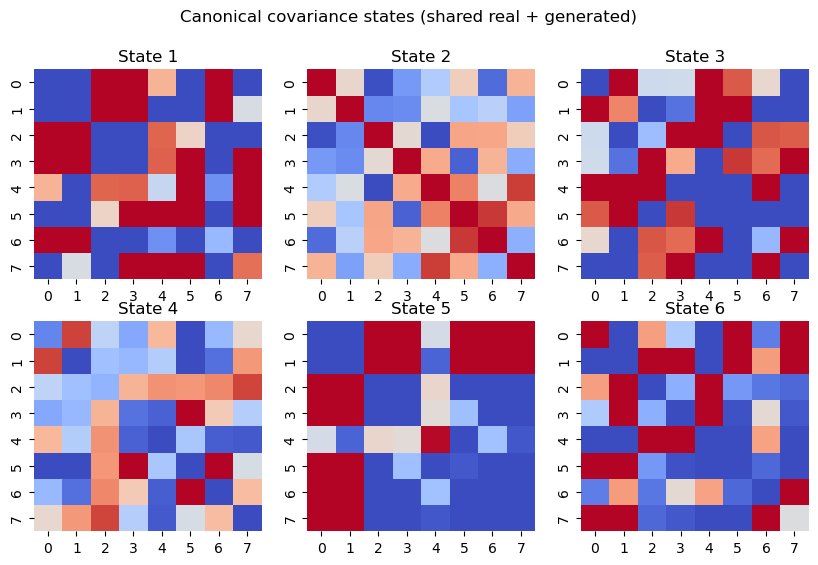

In [ ]:
centroids = km.cluster_centers_  # (K, d)
fig, axes = plt.subplots(2, 3, figsize=(10,6))
for i, ax in enumerate(axes.flat):
    C = np.zeros((8,8)); C[np.tril_indices(8)] = centroids[i]; C = C + C.T - np.diag(np.diag(C))
    sns.heatmap(C, ax=ax, vmin=-.5, vmax=.5, cmap='coolwarm', cbar=False)
    ax.set_title(f'State {i+1}')
plt.suptitle('Canonical covariance states (shared real + generated)')

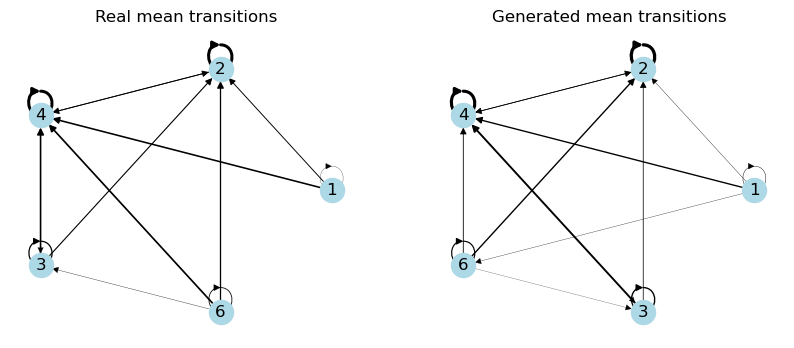

In [11]:
import networkx as nx

T_real_mean = results_2['T_real_mean']
T_gen_mean = results_2['T_gen_mean']

def plot_transition_graph(T, title):
    G = nx.DiGraph()
    for i in range(T.shape[0]):
        for j in range(T.shape[1]):
            if T[i,j] > 0.05:  # threshold weak transitions
                G.add_edge(i+1, j+1, weight=T[i,j])
    pos = nx.circular_layout(G)
    widths = [3*G[u][v]['weight'] for u,v in G.edges()]
    nx.draw(G, pos, with_labels=True, width=widths, node_color='lightblue')
    plt.title(title)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plot_transition_graph(T_real_mean, 'Real mean transitions')
plt.subplot(1,2,2); plot_transition_graph(T_gen_mean, 'Generated mean transitions')


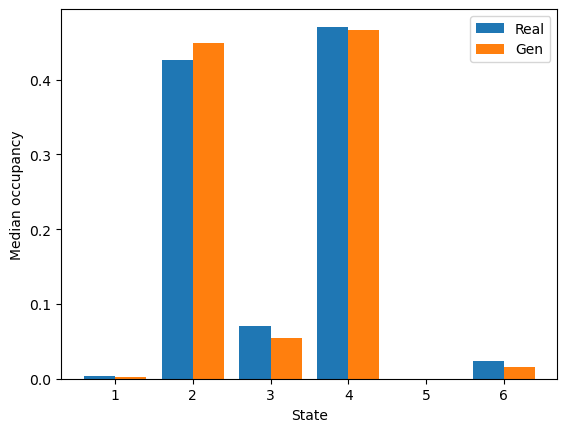

In [14]:
occ_real_med = results_2['occ_real_med']
occ_gen_med = results_2['occ_gen_med']

plt.bar(np.arange(1,7)-0.2, occ_real_med, width=0.4, label='Real')
plt.bar(np.arange(1,7)+0.2, occ_gen_med, width=0.4, label='Gen')
plt.xlabel('State'); plt.ylabel('Median occupancy'); plt.legend()

In [ ]:
## PSD
psd_real, psd_fake, freqs = calculate_psd_different_methods(x, x_gen, N_SUBJECTS, psd_method='reverse_first')
# ---------- utilities (same as before) ----------
def zscore_cols(A):
    mu = A.mean(0, keepdims=True); sd = A.std(0, keepdims=True)
    keep = (sd > 0)
    return (A[:, keep[0]] - mu[:, keep[0]]) / sd[:, keep[0]]

def condensed_corr_dists(X):
    return pdist(X, metric='correlation')

def knn_radius(X, Y, k=5):
    D = cdist(X, Y, metric='correlation')
    return np.partition(D, k-1, axis=1)[:, k-1]

# ---------- spectral feature builders ----------
bands = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}

def bandpower_topo(psd, freqs):
    # psd: (n_subj, 8, n_freq)  -> (n_subj, 40)
    total = psd.sum(axis=-1, keepdims=True) + 1e-12
    feats = []
    for (f1, f2) in bands.values():
        m = (freqs >= f1) & (freqs < f2)
        feats.append(psd[..., m].sum(axis=-1) / total.squeeze(-1))
    return np.concatenate(feats, axis=-1)

def pca_channel_concat(psd, k=5):
    # per-channel PCA on log-PSD, keep k scores/channel  -> (n_subj, 8*k)
    n_subj, n_ch, _ = psd.shape
    out = []
    for ch in range(n_ch):
        X = np.log(psd[:, ch, :] + 1e-12)
        U, S, _ = np.linalg.svd(X - X.mean(0, keepdims=True), full_matrices=False)
        out.append(U[:, :k] * S[:k])
    return np.concatenate(out, axis=1)

# ---------- plotting helper ----------
def plot_distance_distributions(X_real, X_fake, title='', bins=50):
    Xr, Xg = zscore_cols(X_real), zscore_cols(X_fake)
    Dr, Dg = condensed_corr_dists(Xr), condensed_corr_dists(Xg)

    # Coverage: fraction of gen→real kNN radii within P95 of real→real kNN radii
    r_gr = knn_radius(Xg, Xr, k=5)
    r_rr = knn_radius(Xr, Xr, k=5)
    cov = float(np.mean(r_gr <= np.percentile(r_rr, 95)))
    ks  = float(ks_2samp(Dr, Dg).statistic)

    lo, hi = min(Dr.min(), Dg.min()), max(Dr.max(), Dg.max())
    plt.hist(Dr, bins=bins, range=(lo, hi), density=True, alpha=0.60, label='Real–Real')
    plt.hist(Dg, bins=bins, range=(lo, hi), density=True, alpha=0.60, label='Gen–Gen')
    plt.xlabel('Pairwise correlation distance'); plt.ylabel('Density')
    ttl = title + ('' if not title else ' — ') + f'KS={ks:.02f}, Cov={cov:.02f}'
    plt.title(ttl); plt.legend(frameon=False)

# ---------- example usage ----------
# psd_real, psd_fake: (n_subj, 8, 237), freqs: (237,)

# Option A: band-power topography (40-D)
XA_real = bandpower_topo(psd_real, freqs)
XA_fake = bandpower_topo(psd_fake, freqs)

plt.figure(figsize=(6,4))
plot_distance_distributions(XA_real, XA_fake, title='Band-power geometry')
plt.show()

# Option B: PSD shape via PCA per channel (8×k, here k=5 → 40-D)
XB_real = pca_channel_concat(psd_real, k=5)
XB_fake = pca_channel_concat(psd_fake, k=5)

plt.figure(figsize=(6,4))
plot_distance_distributions(XB_real, XB_fake, title='PSD-shape (PCA) geometry')
plt.show()

In [ ]:

# Inputs:
# psd_real, psd_gen: arrays (n_subj, n_ch=8, n_freq=237)
# freqs: (237,)

# --- helper: z-score columns, drop zero-var features
def zscore_cols(A):
    mu = A.mean(0, keepdims=True); sd = A.std(0, keepdims=True)
    keep = (sd > 0)
    return (A[:, keep[0]] - mu[:, keep[0]]) / sd[:, keep[0]]

def condensed_corr_dists(X):  # within-set distances
    return pdist(X, metric='correlation')

def knn_radius(X, Y, k=5):
    D = cdist(X, Y, metric='correlation')
    return np.partition(D, k-1, axis=1)[:, k-1]

# --- Option A: 40-D band-power topography
bands = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
def bandpower_topo(psd, freqs):
    bp = []
    total = psd.sum(axis=-1, keepdims=True) + 1e-12  # fractional power
    for (f1,f2) in bands.values():
        m = (freqs>=f1) & (freqs<f2)
        bp.append(psd[..., m].sum(axis=-1, keepdims=False) / total.squeeze(-1))
    # shape: list of 5 arrays (n_subj, n_ch) -> (n_subj, 5*n_ch)
    return np.concatenate(bp, axis=-1)

# Xr = bandpower_topo(psd_real, freqs)  # (n_subj, 40)
# Xg = bandpower_topo(psd_fake,  freqs)

# --- Option B: PSD-shape embedding via PCA per channel (simple SVD keep k=5)
def pca_channel_concat(psd, k=5):
    n_subj, n_ch, n_f = psd.shape
    feats = []
    for ch in range(n_ch):
        X = np.log(psd[:, ch, :] + 1e-12)  # (n_subj, n_f)
        U, S, Vt = np.linalg.svd(X - X.mean(0, keepdims=True), full_matrices=False)
        feats.append((U[:, :k] * S[:k]).astype(float))  # scores
    return np.concatenate(feats, axis=1)  # (n_subj, n_ch*k) e.g., 40-D

Xr = pca_channel_concat(psd_real, k=5)
Xg = pca_channel_concat(psd_real,  k=5)

# --- Geometry metrics
Xr_z, Xg_z = zscore_cols(Xr), zscore_cols(Xg)
Dr, Dg = condensed_corr_dists(Xr_z), condensed_corr_dists(Xg_z)
KS = ks_2samp(Dr, Dg).statistic
r_gr = knn_radius(Xg_z, Xr_z, k=5); r_rr = knn_radius(Xr_z, Xr_z, k=5)
coverage = float(np.mean(r_gr <= np.percentile(r_rr, 95)))
ratio = float(np.median(r_gr) / (np.percentile(r_rr, 75) + 1e-6))
print({'KS': KS, 'coverage': coverage, 'knn_ratio': ratio})
from umap import UMAP
import matplotlib.pyplot as plt

# Xr, Xg from your Option A (40-D band-power); z-score columns first
def zscore(A):
    m, s = A.mean(0, keepdims=True), A.std(0, keepdims=True)
    s[s==0] = 1.0
    return (A - m) / s

Xr_z, Xg_z = zscore(Xr), zscore(Xg)
X = np.vstack([Xr_z, Xg_z])
y = np.array([0]*len(Xr_z) + [1]*len(Xg_z))  # 0=Real, 1=Gen

emb = UMAP(n_neighbors=15, min_dist=0.1, metric='correlation', random_state=0).fit_transform(X)
plt.figure(figsize=(5,4))
plt.scatter(emb[y==0,0], emb[y==0,1], s=12, alpha=0.6, label='Real')
plt.scatter(emb[y==1,0], emb[y==1,1], s=12, alpha=0.6, label='Gen')
plt.legend(frameon=False); plt.axis('off'); plt.title('UMAP of band-power geometry')
plt.show()

bands = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
def bandpower_topo(psd, freqs):
    bp = []
    total = psd.sum(axis=-1, keepdims=True) + 1e-12  # fractional power
    for (f1,f2) in bands.values():
        m = (freqs>=f1) & (freqs<f2)
        bp.append(psd[..., m].sum(axis=-1, keepdims=False) / total.squeeze(-1))
    return np.array(bp).transpose(1, 2, 0)
bp_real = bandpower_topo(psd_real, freqs)
bp_gen = bandpower_topo(psd_fake, freqs)
import matplotlib.pyplot as plt

# bp_real/gen: (n_subj, 8, 5) fractional power per band per channel
mean_r = bp_real.mean(axis=0)  # (8,5)
mean_g = bp_gen.mean(axis=0)
diff   = mean_g - mean_r

fig, axes = plt.subplots(1,3, figsize=(10,3), constrained_layout=True)
im0 = axes[0].imshow(mean_r, vmin=0, vmax=np.max(mean_r), aspect='auto')
axes[0].set_title('Mean Real'); axes[0].set_xlabel('Band'); axes[0].set_ylabel('Channel')
im1 = axes[1].imshow(mean_g, vmin=0, vmax=np.max(mean_r), aspect='auto')
axes[1].set_title('Mean Generated'); axes[1].set_xlabel('Band')
m = np.max(np.abs(diff))
im2 = axes[2].imshow(diff, vmin=-m, vmax=m, cmap='coolwarm', aspect='auto')
axes[2].set_title('Difference (Gen−Real)'); axes[2].set_xlabel('Band')
fig.colorbar(im1, ax=axes[:2].ravel().tolist(), fraction=0.025, pad=0.02, label='Frac. power')
fig.colorbar(im2, ax=axes[2], fraction=0.025, pad=0.02, label='Δ frac. power')
plt.show()

import numpy as np
from scipy.signal import savgol_filter

def iaf_per_subject(psd, freqs, chans=(6,7,0,1), fmin=8.0, fmax=13.0):
    """
    psd: (n_subj, 8, n_freq) absolute power
    freqs: (n_freq,)
    chans: indices for P/O-ish channels e.g., (P1,P2,O1,O2) -> adapt to your montage
    returns: IAF per subject (Hz)
    """
    band = (freqs >= fmin) & (freqs <= fmax)
    f = freqs[band]
    iaf = np.full(psd.shape[0], np.nan)
    for s in range(psd.shape[0]):
        # average posterior channels, log-transform, smooth
        p = psd[s, chans].mean(axis=0)
        lp = np.log(p + 1e-12)
        lp = savgol_filter(lp, 11, 3)  # window, polyorder
        # search in alpha range
        idx = np.argmax(lp[band])
        iaf[s] = f[idx]
    return iaf

iaf_real = iaf_per_subject(psd_real, freqs)
iaf_fake = iaf_per_subject(psd_fake, freqs)